# Grass Growth rate Analysis
***
This notebook processes the data from the in-game experiment to determine the rate constant in the logistic growth model of grass. See the markdown file for details about the experiment itself.

## Imports
***

In [27]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
import scipy as sp

In [28]:
#set serif font
plt.rcParams["font.family"]="serif"
plt.rcParams["mathtext.fontset"]="dejavuserif"

In [29]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

## Load Data
***
The file `grass_growth.csv` contains two columns. The first is time since the experiment began, and the second is the number of grass blocks in the 30x30 test area. We'll load the file and separate it into two 1D numpy arrays.

In [30]:
with open("grass_growth.csv", "r") as f:
    whole_file = np.loadtxt(f, delimiter=",")

time = whole_file[:, 0]
grass_frac = whole_file[:, 1]

## Plot Grass Population vs Time
***
Let's take a moment to go into some more detail about the logistic function. We know its derivative is

$$\dot{y}=ky\left(1-\frac{y}{p}\right)$$

But what is the actual expression for $y$? That expression for $\dot{y}$ is a nonlinear ordinary differential equation (nonlinear being synonymous with pain-in-the-neck). Luckily, someone else has already solved it:

$$y = \frac{p}{1+\left(\frac{p-y_0}{y_0}\right)\exp(-kt)}$$

Where $y_0$ is a new constant that just shifts the curve left and right.

Here's what $y$ looks like:

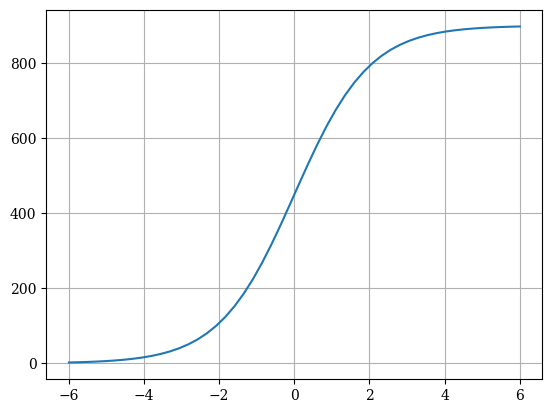

In [31]:
def logistic(t, k, y0):
    return 900/(1 + (900-y0) / y0 * np.exp(-k*t))

f, ax = plt.subplots()

x_example = np.linspace(-6, 6)
y_example = logistic(x_example, 1, 450)

ax.plot(x_example, y_example)
ax.grid(True)

plt.show()

***
If we plot the grass population vs time, we should see something similar:

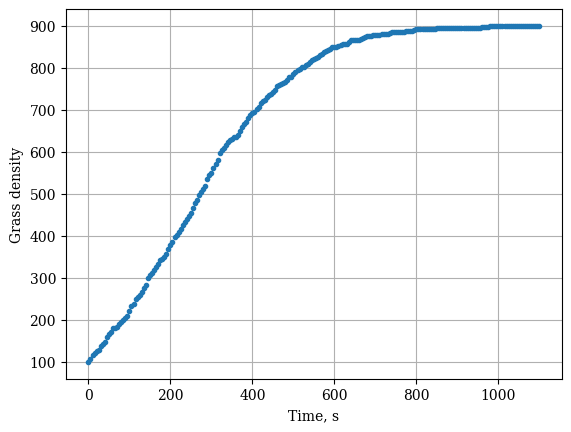

In [32]:
f, ax = plt.subplots()

ax.plot(time, grass_frac, ".")
ax.grid(True)
ax.set_xlabel("Time, s")
ax.set_ylabel("Grass density")

plt.show()

## Fitting logistic function to grass density
***
We should be able to get a good estimate for $k$ by fitting this expression for $y$ to the grass data. We'll use `scipy.optimize.curve_fit` for this.

We'll need some initial guesses for $k$ and $y_0$. We can estimate $y_0$ from the graph above - $y_0$ is the population at time $t=0$. We can also estimate k from the graph - $\dot{y}=0.25k$ at $y=0.5p$.

From there, we can call `curve_fit` with the logistic function we defined earlier and the grass data, and get our value for $k$:

In [33]:
#estimate x0 and k from the graph above
guess = [0.008, 100]

solution = sp.optimize.curve_fit(logistic, time, grass_frac, p0 = guess)

# the +/- here are standard deviations for parameter estimates. see scipy.optimize.curve_fit documentation.
print("k = {0:.3} +/- {1:.3}\nx0 = {2:.3} +/- {3:.3}".format(solution[0][0], np.sqrt(solution[1][0,0]),
                                                             solution[0][1], np.sqrt(solution[1][1,1])))

k = 0.00773 +/- 2.02e-05
x0 = 1.19e+02 +/- 0.606


***
Now let's see how the fit lines up:

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


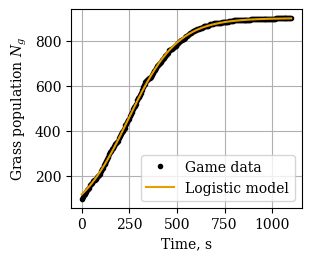

In [34]:
grass_fit = logistic(time, solution[0][0], solution[0][1])

f, ax = plt.subplots(figsize=(3,2.5), layout="constrained")
ax.set_prop_cycle(wong_cycle)

ax.plot(time, grass_frac, ".", label="Game data")
ax.plot(time, grass_fit, "-", label="Logistic model")

ax.grid(True)
ax.set_xlabel("Time, s")
ax.set_ylabel("Grass population $N_g$")

ax.legend()

#plt.show()
plt.savefig("grass_logistic.eps")
plt.savefig("grass_logistic.pdf")

***
Pretty good.

## Fitting logistic derivative to growth rate
***
There's another approach we could take. From the grass cover data, we can calculate the grass growth rate. We can then plot the grass cover vs. the grass growth rate, i.e. plotting the grass cover vs. its own derivative. From the equation

$\dot{y} = ky(1-\frac{y}{p})$

We expect to see a parabola. We can fit a parabola, $y=k(x-\frac{x^2}{p})$, and ideally we should get a value for k close to what we got from fitting the grass cover data.

We'll start by calculating those derivatives.

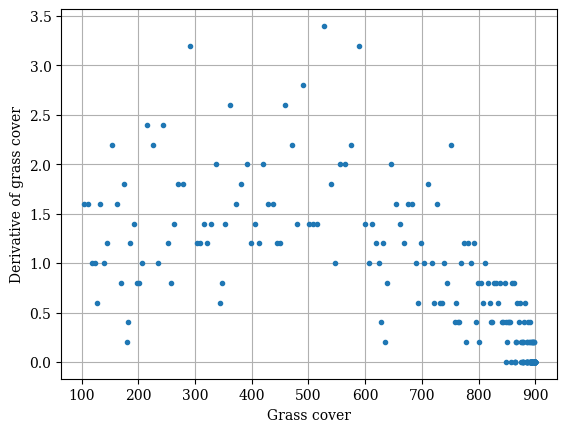

In [35]:
grass_deriv = np.empty(grass_frac.size-1)
grass_cover_midpoint = np.empty(grass_frac.size-1)

#we will calculate the derivatives at the midpoint between adjacent data points
for i in range(0, grass_frac.size-1):
    #change in grass cover over change in time
    grass_deriv[i] = (grass_frac[i+1] - grass_frac[i]) / 5

    #get the grass cover at the midpoint between the two data points
    grass_cover_midpoint[i] = (grass_frac[i+1] + grass_frac[i]) / 2

f, ax = plt.subplots()

ax.plot(grass_cover_midpoint, grass_deriv, ".")
ax.grid(True)
#ax.axis([-20, 920, -0.1, 3.6])
ax.set_xlabel("Grass cover")
ax.set_ylabel("Derivative of grass cover")

plt.show()

***
Derivatives tend to make noise much more prominent, hence the large amount of scatter in the graph. Still, there is a distinct parabolic shape. We'll go ahead and perform a fit and see what we get for k:

In [36]:
def parabola(x, k):
    return k * (x - x**2/900)

#We will use the same guess as before for k
solution2 = sp.optimize.curve_fit(parabola, grass_cover_midpoint, grass_deriv, p0 = [0.008])

print("k = {0:.3} +/- {1:.3}".format(solution2[0][0], np.sqrt(solution2[1][0,0])))

k = 0.00783 +/- 0.000235


Pretty close to what we had before, but a somewhat larger confidence interval. Let's see how the graphs line up:

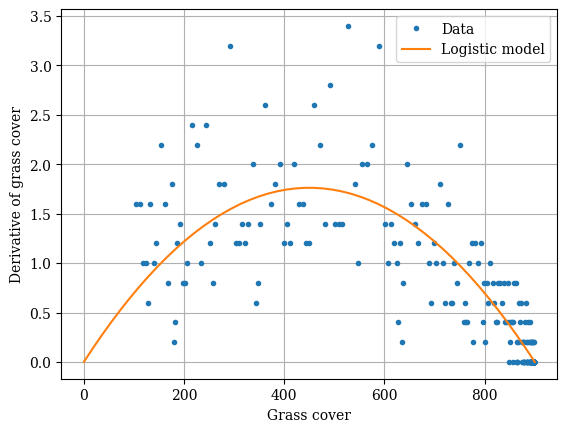

In [37]:
grass_deriv_fit = parabola(np.linspace(0,900), solution2[0][0])

f, ax = plt.subplots()

ax.plot(grass_cover_midpoint, grass_deriv, ".", label="Data")
ax.plot(np.linspace(0,900), grass_deriv_fit, "-", label="Logistic model")

ax.grid(True)
#ax.axis([-0.1, 1.1, -0.0001, 0.004])
ax.set_xlabel("Grass cover")
ax.set_ylabel("Derivative of grass cover")

ax.legend()

plt.show()

## JMAK Equation
***
The Johnson-Mehl-Avrami-Kolmogorov equation is popular for modelling phase transformations in materials science. The assumptions underlying this model, a phase front expanding out spherically from a nucleation site, are reminiscent of the spreading of grass from a single block.

The equation is as follows:

$$f=1-e^{-kt^n}$$

Where $f$ is the fraction transformed, $k$ is a constant related to the transformation rate, and $n$ is a constant related to the dimensionality of the transformation - ideally, $n-1$ equals the dimensionality of the transformation. In our case, $f$ will be replaced by $\frac{N_g}{A}$, and we will have $n=3$.

We will also replace $t$ with $t-t_0$ to allow shifting to different times.

Here's what the JMAK equation looks like:

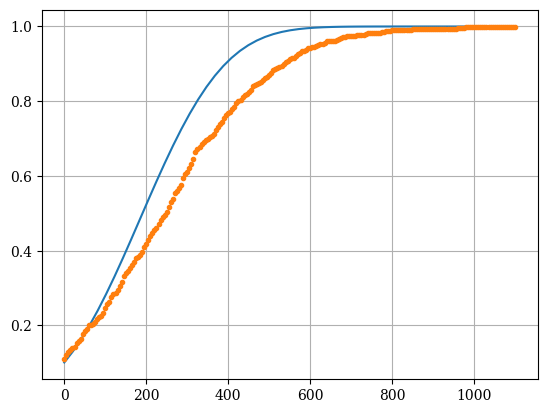

In [38]:
def JMAK(t, k, t0):
    return 1-np.exp(-k*(t-t0)**3)

f, ax = plt.subplots()

x_example = np.linspace(0, 1000)
y_example = JMAK(x_example, 0.00000001, -220)

ax.plot(x_example, y_example)
ax.grid(True)

ax.plot(time, grass_frac/900, ".")

plt.show()

This is superficially similar to the logistic model. I've come up with these starting values via trial and error, and we can try fitting this equation to the data:

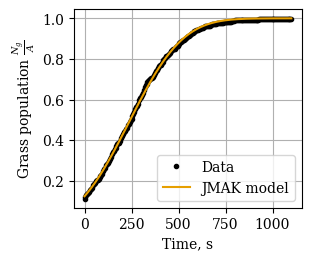

In [39]:
guess = [0.00000001, -220]

solution3 = sp.optimize.curve_fit(JMAK, time, grass_frac/900, p0=guess)

jmak_fit = JMAK(time, solution3[0][0], solution3[0][1])

f, ax = plt.subplots(figsize=(3,2.5), layout="constrained")
ax.set_prop_cycle(wong_cycle)

ax.plot(time, grass_frac/900, ".", label="Data")
ax.plot(time, jmak_fit, "-", label="JMAK model")

ax.grid(True)
ax.set_xlabel("Time, s")
ax.set_ylabel("Grass population $\\frac{N_g}{A}$")

ax.legend()

This is a pretty good fit.

There are two major roadblocks to using the JMAK equation. First, we need a differential equation describing $\dot{N}_g$ purely in terms of $N_g$. To the best of my knowledge, no such equations exists for the JMAK model, as the derivation is based around a derivative w.r.t. time.

Second, we require that $\lambda=0$ at $N_g=0$. This may or may not be the case for the JMAK equation.